# Assignment 2 - Network Connectivity

In this assignment you will go through the process of importing and analyzing an internal email communication network between employees of a mid-sized manufacturing company. 
Each node represents an employee and each directed edge between two nodes represents an individual email. The left node represents the sender and the right node represents the recipient. We will also store the timestamp of each email. 

In [1]:
import networkx as nx

#!head assets/email_network.txt

### Question 1

Using networkx, load up the directed multigraph from `assets/email_network.txt`. Make sure the node names are strings.

*This function should return a directed multigraph networkx graph.*

In [2]:
# create pd df for the txt file 
import pandas as pd
G_df = pd.read_csv('assets/email_network.txt', sep='\t', header=0, names=['Sender', 'Recipient', 'time'])
G_df.head()

,Sender,Recipient,time
0,1,2,1262454010
1,1,3,1262454010
2,1,4,1262454010
3,1,5,1262454010
4,1,6,1262454010


In [3]:
# create multi directed graph from txt file 
email = nx.read_edgelist('assets/email_network.txt', data=[('time',int)],
                         create_using = nx.MultiDiGraph())

In [4]:
# check taht graph is both directed, and multigraph 
email.is_directed(), email.is_multigraph()

(True, True)

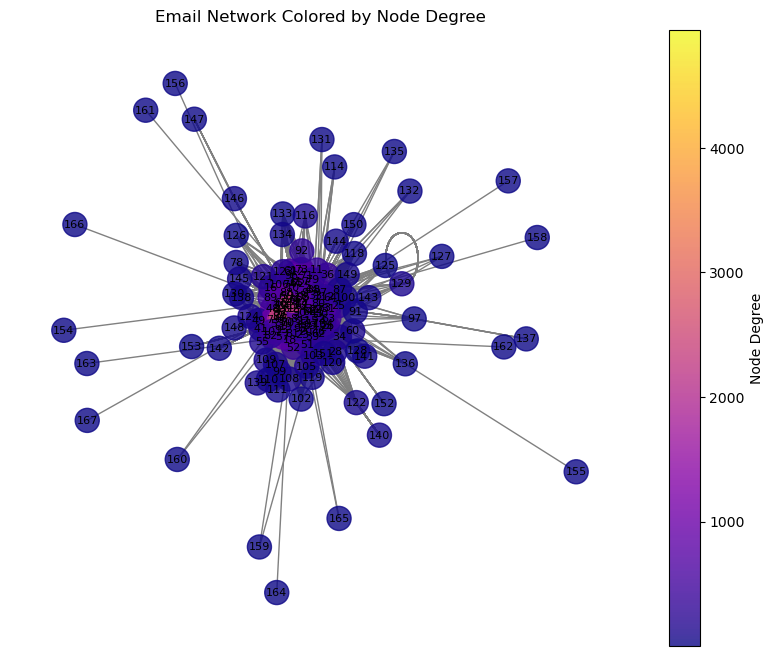

In [63]:
import matplotlib.pyplot as plt 
# Draw the graph
# Optional: layout for nice positioning
G = email.to_undirected()

# Extract degree values for coloring
degrees = dict(G.degree())
node_colors = [degrees[node] for node in G.nodes()]

pos = nx.spring_layout(email.to_undirected())  # Use seed for consistent layout

plt.figure(figsize=(10, 8))

nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.plasma,
                               node_size=300, alpha=0.8)
edges = nx.draw_networkx_edges(G, pos, edge_color="gray")
labels = nx.draw_networkx_labels(G, pos, font_size=8)

plt.colorbar(nodes, label='Node Degree')
plt.title("Email Network Colored by Node Degree")
plt.axis("off")
plt.show()

# nx.draw(email.to_undirected(), pos, with_labels=True, node_size=300, node_color="skyblue", edge_color="gray", font_size=8)
# plt.title("Undirected version of Email Networks")
# plt.show()

In [5]:
def answer_one():
    
    # YOUR CODE HERE
    email = nx.read_edgelist('assets/email_network.txt', data=[('time',int)],
                         create_using = nx.MultiDiGraph())
    # raise NotImplementedError()
    return email

In [6]:
ans_one = answer_one()

In [7]:
ans_one

### Question 2

How many employees are represented in the network?

How many `sender`->`recipient` pairs of employees are there in the network such that `sender` sent at least one email to `recipient`? Note that even if a `sender` sent multiple messages to a `recipient`, they should only be counted once. You should **not** exclude cases where an employee sent emails to themselves from this [email] count. 

*This function should return a tuple with two integers (#employees, # `sender`->`recipient` pairs).*

In [8]:
import numpy as np
# counts number of nodes 
# ie. no. of employees
len(list(email.nodes()))

167

In [9]:
# sets remove duplicate edges (ie pairs of nodes) 
# len to count how many such unique edges there are in the set 
len(set(list(email.edges())))

5784

In [10]:
def answer_two():
    # YOUR CODE HERE
    employees = len(list(email.nodes())) 
    pairs = len(set(list(email.edges())))
    
    return (employees, pairs) 
    
    # raise NotImplementedError()

In [11]:
ans_two = answer_two()


In [12]:
ans_two

(167, 5784)

### Question 3

* Part 1. Assume that information in this company can only be exchanged through email.

    When an employee sends an email to another employee, a communication channel has been created, allowing the sender to provide information to the reciever, but not viceversa. 

    Based on the emails sent in the data, is it possible for information to go from every employee to every other employee?


* Part 2. Now assume that a communication channel established by an email allows information to be exchanged both ways. 

    Based on the emails sent in the data, is it possible for information to go from every employee to every other employee?


*This function should return a tuple of bools (part1, part2).*

In [13]:
# part 1: is the directed graph strongly connected? 
nx.is_strongly_connected(email)

False

In [14]:
# part 2: is this directed graph weakly connected? 
# after remove the direction arrows 
nx.is_weakly_connected(email)

True

In [15]:
def answer_three():
    # YOUR CODE HERE
    return(nx.is_strongly_connected(email), nx.is_weakly_connected(email))
    # raise NotImplementedError()

In [16]:
ans_three = answer_three()


In [17]:
ans_three

(False, True)

### Question 4

How many nodes are in the largest weakly connected component of the graph?

*This function should return an int.*

In [18]:
# find out what components are weakly connected 
len(sorted(nx.weakly_connected_components(email))[0])

167

In [19]:
def answer_four():
    # YOUR CODE HERE
    # since the whole graph is weakly connected 
    # there is only 1 weakly connected component 
    # which is the set itself 
    return len(sorted(nx.weakly_connected_components(email))[0])
    
    # raise NotImplementedError()

In [20]:
ans_four = answer_four()

In [21]:
ans_four

167

### Question 5

How many nodes are in the largest strongly connected component?

*This function should return an int*

In [22]:
# find out the components that are strongly connected 
# sorted by largest component first 
strong_comp = sorted(nx.strongly_connected_components(email), key=len, reverse=True)
len(strong_comp[0])

126

In [23]:
def answer_five():
    # YOUR CODE HERE
    # find out the components that are strongly connected 
    # sorted by largest component first 
    strong_comp = sorted(nx.strongly_connected_components(email), key=len, reverse=True)
    return len(strong_comp[0])

    # raise NotImplementedError()

In [24]:
ans_five = answer_five()


In [25]:
ans_five

126

### Question 6

Using the NetworkX functions `strongly_connected_components` and `subgraph`, find the subgraph of nodes in the largest strongly connected component. 
Call this graph G_sc.

*This function should return a networkx MultiDiGraph named G_sc.*

In [26]:
# find this largest component first 
comp = sorted(nx.strongly_connected_components(email), key=len, reverse=True)[0]
# create a subgraph of it 
G_sc = email.subgraph(list(comp))
# check if is directed and is multi graph 
G_sc.is_directed(), G_sc.is_multigraph()

(True, True)

In [27]:
def answer_six():
    # YOUR CODE HERE
    # find this largest component first 
    comp = sorted(nx.strongly_connected_components(email), key=len, reverse=True)[0]
    # create a subgraph of it 
    G_sc = email.subgraph(list(comp))
    return G_sc
    
    # raise NotImplementedError()

In [28]:
ans_six = answer_six()
assert type(ans_six) == nx.MultiDiGraph , "Your return type should be a MultiDiGraph object"


In [29]:
# list(G_sc.edges)

### Question 7

What is the average distance between nodes in G_sc?

*This function should return a float.*

In [30]:
nx.average_shortest_path_length(G_sc)

1.6461587301587302

In [31]:
def answer_seven():
    # YOUR CODE HERE
    return nx.average_shortest_path_length(G_sc) 
    # raise NotImplementedError()

In [32]:
ans_seven = answer_seven()


### Question 8

What is the largest possible distance between two employees in G_sc?

*This function should return an int.*

In [33]:
nx.diameter(G_sc)

3

In [34]:
def answer_eight():
    # YOUR CODE HERE
    return nx.diameter(G_sc)
    # raise NotImplementedError()

In [35]:
ans_eight = answer_eight()


### Question 9

What is the set of nodes in G_sc with eccentricity equal to the diameter?

*This function should return a set of the node(s).*

In [36]:
# these nodes are in the periphery 
set(nx.periphery(G_sc))

{'129', '134', '97'}

In [37]:
def answer_nine():
    # YOUR CODE HERE
    return set(nx.periphery(G_sc))
    # raise NotImplementedError()

In [38]:
ans_nine = answer_nine()
assert type(ans_nine) == set, "Student answer must return a set"

### Question 10

What is the set of node(s) in G_sc with eccentricity equal to the radius?

*This function should return a set of the node(s).*

In [39]:
# nodes that are in the center 
set(nx.center(G_sc))

{'38'}

In [40]:
def answer_ten():
    # YOUR CODE HERE
    return set(nx.center(G_sc))
    # raise NotImplementedError()

In [41]:
ans_ten = answer_ten()
assert type(ans_ten) == set, "Student answer must return a set"

### Question 11

Which node in G_sc has the most shortest paths to other nodes whose distance equal the diameter of G_sc?


For the node with the most such shortest paths, how many of these paths are there?


*This function should return a tuple (name of node, number of paths).*

In [42]:
diameter = nx.diameter(G_sc)
shortest_paths = sorted(nx.shortest_path_length(G_sc))
result = {
    source: sum(1 for dist in targets.values() if dist == diameter)
    for source, targets in shortest_paths
}
sorted(result.items(), key=lambda x: x[1], reverse=True)[0]

('97', 63)

In [43]:
def answer_eleven():
    # YOUR CODE HERE
    diameter = nx.diameter(G_sc)
    shortest_paths = sorted(nx.shortest_path_length(G_sc))
    result = {
        source: sum(1 for dist in targets.values() if dist == diameter)
        for source, targets in shortest_paths
    }
    return sorted(result.items(), key=lambda x: x[1], reverse=True)[0]
    # raise NotImplementedError()

In [44]:
ans_eleven = answer_eleven()
assert type(ans_eleven) == tuple, "Student answer must be a tuple"

### Question 12

Suppose you want to prevent communication flow from the node that you found in question 11 to node 10. What is the smallest number of nodes you would need to remove from the graph (you're not allowed to remove the node from the previous question or 10)? 

*This function should return an integer.*

In [45]:
# smallest no. of nodes to disconnect 
nx.node_connectivity(email, '97','38')
#nx.minimum_node_cut(email, '97', '38')

1

In [46]:
def answer_twelve():
    # YOUR CODE HERE
    return nx.node_connectivity(email, '97','38')
    # raise NotImplementedError()

In [47]:
ans_twelve = answer_twelve()


### Question 13

Convert the graph G_sc into an undirected graph by removing the direction of the edges of G_sc. Call the new graph G_un. 


*This function should return a networkx Graph.*

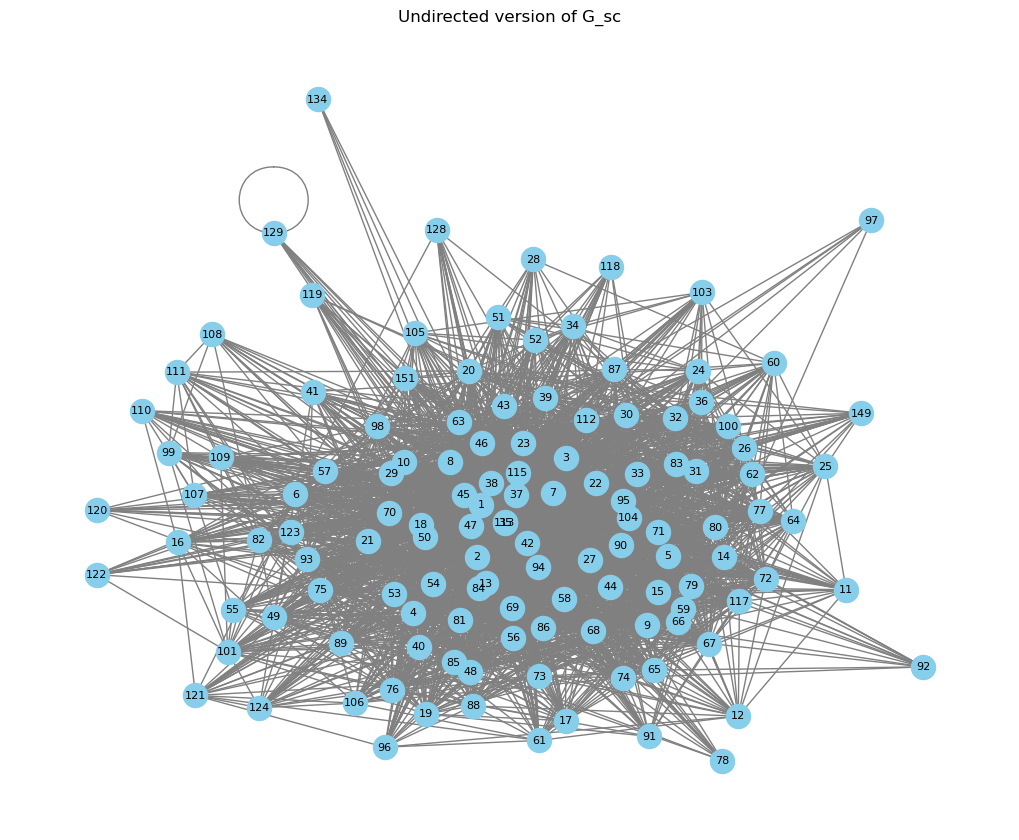

In [48]:
# convert G_sc to undirected 
# also convert G_sc to DiGraph first by removing parallel edges 
# this gives a simple undirected graph 
G_un = nx.DiGraph(G_sc).to_undirected()

import matplotlib.pyplot as plt 
# Draw the graph
# Optional: layout for nice positioning
pos = nx.spring_layout(G_un, seed=42)  # Use seed for consistent layout

plt.figure(figsize=(10, 8))
nx.draw(G_un, pos, with_labels=True, node_size=300, node_color="skyblue", edge_color="gray", font_size=8)
plt.title("Undirected version of G_sc")
plt.show()

In [49]:
print(type(G_un)) 

<class 'networkx.classes.graph.Graph'>


In [50]:
def answer_thirteen():
    # YOUR CODE HERE
    G_un = nx.DiGraph(G_sc).to_undirected()
    return G_un
    # raise NotImplementedError()

In [51]:
ans_thirteen = answer_thirteen()
assert type(ans_thirteen) == nx.Graph , "Your return type should be a Graph object"


### Question 14

What is the transitivity and average clustering coefficient of graph G_un?

*This function should return a tuple (transitivity, avg clustering).*     
*Note: DO NOT round up your answer.*

In [52]:
nx.average_clustering(G_un)
nx.transitivity(G_un)

0.570111160700385

In [53]:
def answer_fourteen():
    # YOUR CODE HERE
    return (nx.transitivity(G_un), nx.average_clustering(G_un))
    raise NotImplementedError()

In [54]:
ans_fourteen = answer_fourteen()
assert type(ans_fourteen) == tuple, "Student answer must be a tuple"
